<a href="https://colab.research.google.com/github/MaseleCS-afk/carisurg-portfolio/blob/main/week0_triage_eda_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Respiratory Rate Data Cleaning - Week 0, Assignment 2

In [ ]:
# Confirm Python version >= 3.10
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [2]:
# Import vital libraries
import pandas as pd # data handling
import numpy as np # numerical operations (NaNs,Arrays)
import matplotlib.pyplot as plt # visualization

print('Libraries imported successfully')



Libraries imported successfully


In [4]:
# Load dataset, display shape and column names
FILE_PATH = '/content/EmergencyTriageDataset_Reduced_Dirty.csv'
df_raw = pd.read_csv(FILE_PATH)

# Display dataset information
print('Dataset successfully loaded!')
print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns') # dataset size check
print(f'Columns: {list(df_raw.columns)}') #confirming its structure
#

Dataset successfully loaded!
Shape: 2205 rows x 11 columns
Columns: ['ID', 'Age', 'Gender', 'GCS', 'SBP', 'DBP', 'MAP', 'pulse', 'Temp', 'RR', 'Fio2']


In [5]:
# (RR) - Respiratory Rate Cleaning
COLUMN = 'RR'   # RR = Respiratorty Rate
VALID_MIN = 5   # Min RR
VALID_MAX = 60  # Max RR

print(f"=== Cleaning: {COLUMN} ===")
print(f"Unique Values: {df_raw[COLUMN].unique()[:15]}") # scan of raw values
print(f"Null Values: {df_raw[COLUMN].dtype}") # checking data type
print()

# Convert to Numeric
df_raw[COLUMN] = pd.to_numeric(df_raw[COLUMN], errors='coerce') # force numeric, invalid to NaN

#
print(f"After type conversion - NaNs: {df_raw[COLUMN].isnull().sum()}")
print(df_raw[COLUMN].describe()) # summary stats

=== Cleaning: RR ===
Unique Values: [14. 16. 18. 12. 19. 20. 25. 15. 24. nan 30. 29. 40. 26. 38.]
Null Values: float64

After type conversion - NaNs: 22
count    2183.000000
mean       20.262254
std         5.742333
min        12.000000
25%        17.000000
50%        18.000000
75%        21.000000
max        50.000000
Name: RR, dtype: float64


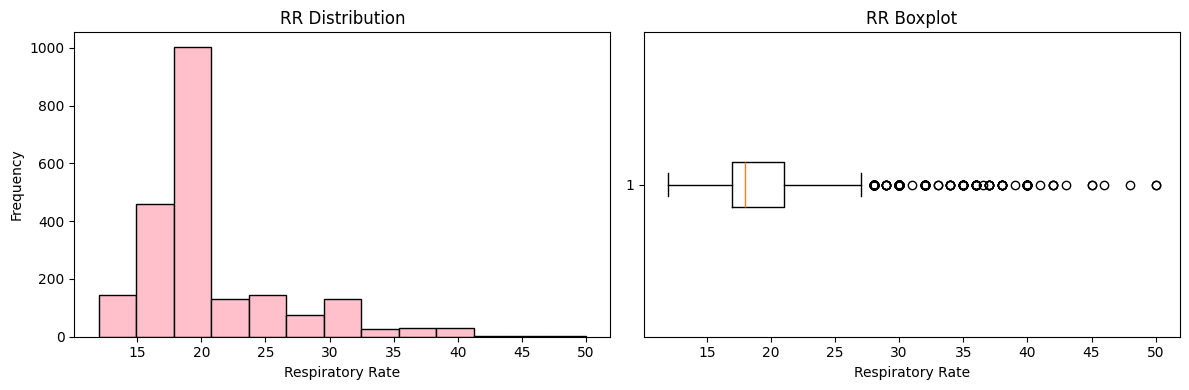

Plot saved as 'rr_distribution.png'


In [6]:
# Visualize Before Cleaning

fig, axes = plt.subplots(1,2, figsize=(12,4))

#Histogram - To show distribution
axes[0].hist(df_raw['RR'].dropna(), bins=13, edgecolor='black', color='pink')
axes[0].set_xlabel('Respiratory Rate')
axes[0].set_ylabel('Frequency')
axes[0].set_title('RR Distribution')

# Boxplot - To show outliers
axes[1].boxplot(df_raw['RR'].dropna(), vert=False) # visual check
axes[1].set_xlabel('Respiratory Rate')
axes[1].set_title('RR Boxplot')

plt.tight_layout()
plt.savefig('rr_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as 'rr_distribution.png'") # For verification

Out-of-range values: 0

After cleaning:
count    2205.000000
mean       20.239683
std         5.718026
min        12.000000
25%        17.000000
50%        18.000000
75%        21.000000
max        50.000000
Name: RR, dtype: float64
NaNs remaining: 0


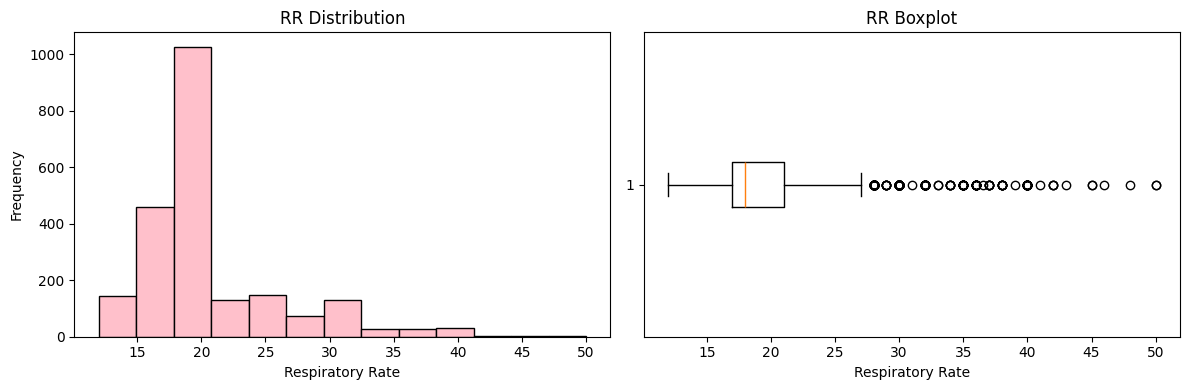

Plot saved as 'rr_distribution_cleaned.png'


In [8]:
# Range Filter

invalid = df_raw[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX)]
print(f"Out-of-range values: {len(invalid)}")

# note: no true outliers found (all values clinically valid)
df_raw.loc[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX), COLUMN] = np.nan

# Impute

impute_value = df_raw[COLUMN].median()
# The following line attempts to use a boolean Series with fillna, but it's incomplete.
# It should be df_raw[COLUMN].fillna(impute_value, inplace=True) to modify the DataFrame directly.
# However, it seems the intention was to use the imputation after the range filter.
# Let's assume the user wants to apply the imputation to the column.
df_raw[COLUMN] = df_raw[COLUMN].fillna(impute_value)

#Visualize after cleaning

print(f"\nAfter cleaning:")
print(df_raw[COLUMN].describe())
print(f"NaNs remaining: {df_raw[COLUMN].isnull().sum()}")
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].hist(df_raw['RR'].dropna(), bins=13, edgecolor='black', color='pink')
axes[0].set_xlabel('Respiratory Rate')
axes[0].set_ylabel('Frequency')
axes[0].set_title('RR Distribution')

axes[1].boxplot(df_raw['RR'].dropna(), vert=False)
axes[1].set_xlabel('Respiratory Rate')
axes[1].set_title('RR Boxplot')

plt.tight_layout()
plt.savefig('rr_distribution_cleaned.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as 'rr_distribution_cleaned.png'")